# Outlier removal with SOR and ScOR

This notebook compares Statistical Outlier Removal (SOR) with the scan-aware Scan Outlier Ratio (ScOR). SOR detects unusually isolated points from local distances. ScOR compares expected and observed point spacing in the scanner's angular grid.


**Implemented by**  
Ronald Tabernig ([@tabernig](https://github.com/tabernig))

**Author(s) of the method**
- SOR: Rusu et al. (2008)
- ScOR: Tabernig and Höfle (2026)

**Original publication of the method**
- Rusu, R.B., Marton, Z.C., Blodow, N., Dolha, M., Beetz, M. (2008). *Towards 3D point cloud based object maps for household environments*. Robotics and Autonomous Systems, 56, 927-941. https://doi.org/10.1016/j.robot.2008.08.005
- Tabernig, R. & Höfle, B. (2026). *Scan Outlier Ratio (ScOR): LiDAR Scanning and Survey-Aware Filtering of Detached Points in Terrestrial and Permanent Laser Scanning Point Clouds*. ISPRS Ann. Photogramm. Remote Sens. Spatial Inf. Sci., XI-2-2026, 155–162, https://doi.org/10.5194/isprs-annals-XI-2-2026-155-2026

## Setup

The example uses the two Trier simulation epochs distributed through the py4dgeo test-data registry. Both LAS return dimensions are loaded because last returns provide the neighborhood candidates used below.

In [1]:
import py4dgeo
import numpy as np

from py4dgeo.util import find_file

py4dgeo.enable_trace(False)
py4dgeo.enable_timeit(False)

In [2]:
# Download and extract the registered example data.
find_file("trier_sim.zip")

dimensions = {
    "return_number": "return_number",
    "number_of_returns": "number_of_returns",
}
epoch_t1 = py4dgeo.read_from_las(
    find_file("trier_sim_epoch_0.laz"), additional_dimensions=dimensions
)
epoch_t2 = py4dgeo.read_from_las(
    find_file("trier_sim_epoch_1.laz"), additional_dimensions=dimensions
)

[2026-09-10 18:26:05][INFO] Reading point cloud from file '/Users/giovannilivibacci/Library/Caches/py4dgeo/trier_sim.zip.unzip/trier_sim_epoch_0.laz'
[2026-09-10 18:26:05][INFO] Reading point cloud from file '/Users/giovannilivibacci/Library/Caches/py4dgeo/trier_sim.zip.unzip/trier_sim_epoch_1.laz'


## Statistical Outlier Removal (SOR)

We run SOR on `epoch_t1` with `k` and `std_dev_multiplier`. `k` controls how many nearest neighbors are used for each point, while `std_dev_multiplier` controls how strict the outlier classification is.

`remove_points=False` keeps all points and returns a per-point inlier/outlier flag for visualization and export.

In [3]:
k = 8
std_dev_multiplier = 1.0
# Keep all points and store the inlier/outlier flag instead.
remove_points = False

epoch_t1, sor_outliers = py4dgeo.statistical_outlier_removal(
    epoch_t1,
    k=k,
    std_dev_multiplier=std_dev_multiplier,
    remove_points=remove_points,
)
print(f"SOR outliers: {sor_outliers.sum()} / {len(sor_outliers)}")

[2026-09-10 18:26:21][INFO] Building KDTree structure with leaf parameter 10
SOR threshold: 0.244
SOR outliers: 34814 / 379809


### Visualize the SOR classification

For responsive plotting, every tenth point is displayed. The calculation and LAS export continue to use all points.

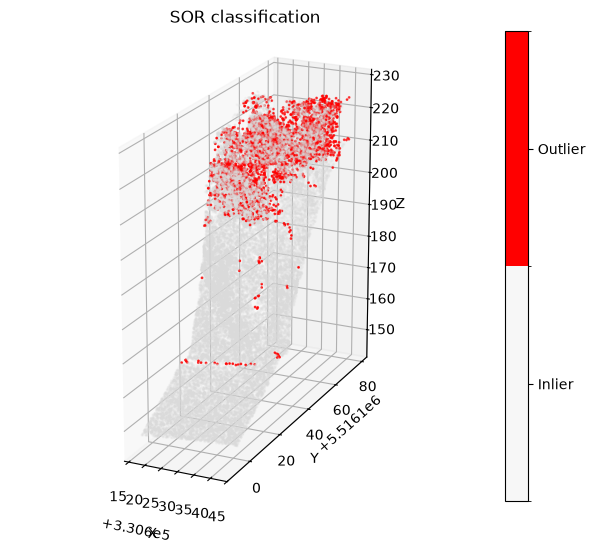

In [5]:
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm, ListedColormap

plot_every_nth_point = 10
view_elev = 20
view_azim = -65
sample_cloud = epoch_t1.cloud[::plot_every_nth_point]
sample_sor_outliers = sor_outliers[::plot_every_nth_point]

fig = plt.figure(figsize=(6, 5), constrained_layout=True)
ax = fig.add_subplot(1, 1, 1, projection="3d")

outlier_cmap = ListedColormap(["#DADADA36", "#FF0000"])
outlier_norm = BoundaryNorm([-0.5, 0.5, 1.5], outlier_cmap.N)
outlier_plot = ax.scatter(
    sample_cloud[:, 0],
    sample_cloud[:, 1],
    sample_cloud[:, 2],
    c=sample_sor_outliers,
    cmap=outlier_cmap,
    norm=outlier_norm,
    s=1,
)
ax.set_title("SOR classification")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.view_init(elev=view_elev, azim=view_azim)
ax.set_box_aspect(np.ptp(sample_cloud, axis=0))
colorbar = fig.colorbar(outlier_plot, ax=ax, ticks=[0, 1])
colorbar.ax.set_yticklabels(["Inlier", "Outlier"])

plt.show()

## Last-return neighborhoods

ScOR can evaluate every search point while using only last or single returns as neighborhood candidates. This keeps the neighborhood focused on sampled surfaces. Epoch slicing preserves the matching additional dimensions and metadata.

In [6]:
def last_returns(
    neighborhood_candidates1: py4dgeo.Epoch,
    return_number_field_name: str,
    number_of_returns_field_name: str,
) -> py4dgeo.Epoch:
    """Return a new Epoch containing only the last returns from the input Epoch."""
    ad = neighborhood_candidates1.additional_dimensions
    rn = ad[return_number_field_name].astype(np.int32).ravel()
    nr = ad[number_of_returns_field_name].astype(np.int32).ravel()
    mask = rn == nr
    last_return_epoch = py4dgeo.Epoch(
        cloud=neighborhood_candidates1.cloud[mask],
        additional_dimensions=ad[mask],
    )
    return last_return_epoch


candidates_t1 = last_returns(epoch_t1, "return_number", "number_of_returns")
candidates_t2 = last_returns(epoch_t2, "return_number", "number_of_returns")

## ScOR parameters

`scan_position` must be expressed in the point cloud coordinate system. `scan_resolution` is the angular spacing in degrees, and `increment` controls the angular neighborhood size. The adjusted resolution below groups two nominal scan steps to avoiding bin-edge aliasing.

In [7]:
scan_position = (330602.0, 5515788.0, 189.0)
scan_resolution = 0.017
adjusted_scan_resolution = 2 * scan_resolution + 0.0028
increment = 1

## Standard ScOR

The standard variant evaluates `t1` against neighborhood candidates from the same epoch. The function returns the ScOR values and the expected and observed distances for each search point. ScOR values are continuous diagnostics and an application-specific threshold can be applied afterwards.

In [14]:
(
    scor_standard,
    expected_standard,
    observed_standard,
) = py4dgeo.scan_outlier_ratio(
    epoch_t1,
    neighborhood_candidate_epochs=candidates_t1,
    scan_position=scan_position,
    scan_resolution=adjusted_scan_resolution,
    increment=increment,
)

### Visualize the standard ScOR classification

The regular standard ScOR result is classified with a threshold of `0.11`. Points with `ScOR < 0.11` are shown as red outliers. All remaining points are shown as grey inliers. The point sample and camera position match the SOR visualization.

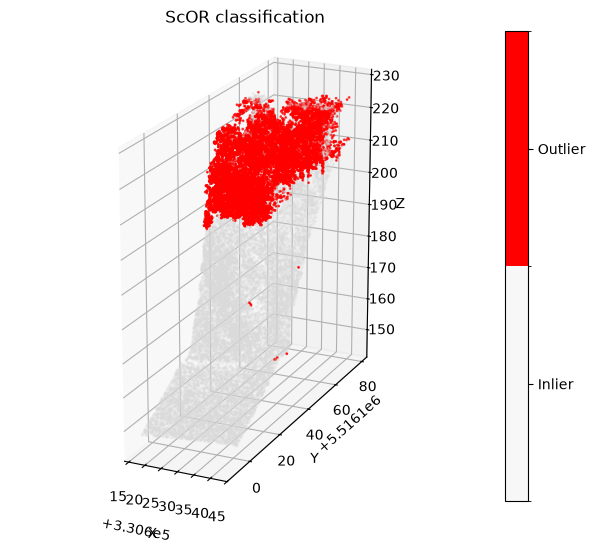

In [15]:
scor_threshold = 0.11
sample_scor_outliers = (scor_standard[::plot_every_nth_point] < scor_threshold).astype(
    int
)

fig = plt.figure(figsize=(6, 5), constrained_layout=True)
ax = fig.add_subplot(1, 1, 1, projection="3d")
scor_plot = ax.scatter(
    sample_cloud[:, 0],
    sample_cloud[:, 1],
    sample_cloud[:, 2],
    c=sample_scor_outliers,
    cmap=outlier_cmap,
    norm=outlier_norm,
    s=1,
)
ax.set_title("ScOR classification")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.view_init(elev=view_elev, azim=view_azim)
ax.set_box_aspect(np.ptp(sample_cloud, axis=0))
colorbar = fig.colorbar(scor_plot, ax=ax, ticks=[0, 1])
colorbar.ax.set_yticklabels(["Inlier", "Outlier"])

plt.show()

## Multitemporal ScOR with one other epoch

Here `t1` remains the search epoch, but its neighborhood candidates come from the single other epoch `t2`. Points without consistent support in the other epoch tend to receive lower ScOR values.

In [16]:
(
    scor_multitemporal_t2,
    expected_multitemporal_t2,
    observed_multitemporal_t2,
) = py4dgeo.scan_outlier_ratio(
    epoch_t1,
    neighborhood_candidate_epochs=candidates_t2,
    scan_position=scan_position,
    scan_resolution=adjusted_scan_resolution,
    increment=increment,
)

## Multitemporal ScOR with aggregated epochs

Passing both available candidate epochs builds a temporally aggregated neighborhood [Tabernig et al. 2025](##references). Aggregation can stabilize persistent surface support while retaining `t1` as the search epoch.

In [11]:
(
    scor_multitemporal_aggregated,
    expected_multitemporal_aggregated,
    observed_multitemporal_aggregated,
) = py4dgeo.scan_outlier_ratio(
    epoch_t1,
    neighborhood_candidate_epochs=(candidates_t1, candidates_t2),
    scan_position=scan_position,
    scan_resolution=adjusted_scan_resolution,
    increment=increment,
)

## Export diagnostics

The ScOR values from all three neighborhood strategies are stored as LAS attributes for inspection in other point cloud software.

In [17]:
output_file = "outlier_removal_sor_scor.laz"
vapc = py4dgeo.Vapc(epoch_t1, voxel_size=0.01)
vapc.out[f"SOR_outlier_k_{k}"] = sor_outliers
vapc.out["ScOR_standard"] = scor_standard
vapc.out["ScOR_multitemporal_t2"] = scor_multitemporal_t2
vapc.out["ScOR_multitemporal_agg"] = scor_multitemporal_aggregated
vapc.save_as_las(output_file)

Adding extra dimension 'SOR_outlier_k_8' of type int64
Adding extra dimension 'ScOR_standard' of type float64
Adding extra dimension 'ScOR_multitemporal_t2' of type float64
Adding extra dimension 'ScOR_multitemporal_agg' of type float64


## References

- Rusu, R. B., Marton, Z. C., Blodow, N., Dolha, M., and Beetz, M. (2008). *Towards 3D point cloud based object maps for household environments*. Robotics and Autonomous Systems, 56, 927–941. https://doi.org/10.1016/j.robot.2008.08.005
- Tabernig, R., Albert, W., Weiser, H., Fritzmann, P., Anders, K., Rutzinger, M., and Höfle, B. (2025). *Temporal aggregation of point clouds improves permanent laser scanning of landslides in forested areas*. Science of Remote Sensing, 12, 100254. https://doi.org/10.1016/j.srs.2025.100254
- Tabernig, R. & Höfle, B. (2026). *Scan Outlier Ratio (ScOR): LiDAR Scanning and Survey-Aware Filtering of Detached Points in Terrestrial and Permanent Laser Scanning Point Clouds*. ISPRS Ann. Photogramm. Remote Sens. Spatial Inf. Sci., XI-2-2026, 155–162, https://doi.org/10.5194/isprs-annals-XI-2-2026-155-2026